In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load the dataset from Google Drive
data = pd.read_csv('/content/drive/MyDrive/creditcard_2023.csv')
print(f"Dataset loaded successfully! Shape: {data.shape}")
data.head()

Dataset loaded successfully! Shape: (568630, 31)


,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [ ]:
# Basic Exploratory Data Analysis (EDA)

print(f"Total transactions: {len(data)}")
print(f"\nFraud vs Normal breakdown:")
print(data['Class'].value_counts().rename({0: 'Normal', 1: 'Fraud'}))
print(f"\nFraud percentage: {data['Class'].mean() * 100:.2f}%")

Total transactions: 568630

Fraud vs Normal breakdown:
Class
Normal    284315
Fraud     284315
Name: count, dtype: int64

Fraud percentage: 50.00%


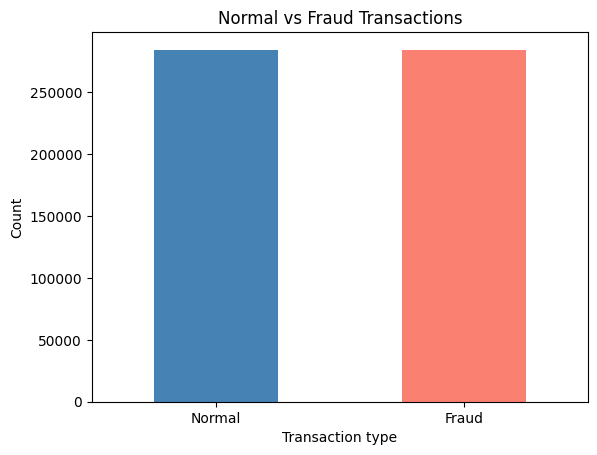

In [ ]:
import matplotlib.pyplot as plt

data['Class'].value_counts().rename({0: 'Normal', 1: 'Fraud'}).plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Normal vs Fraud Transactions')
plt.xlabel('Transaction type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Check for missing values

missing = data.isnull().sum()
total_missing = missing.sum()

print(f"Total missing values: {total_missing}")
if total_missing > 0:
    print("\nMissing values per column:")
    print(missing[missing > 0])
else:
    print("No missing values found in the dataset.")

Total missing values: 0
No missing values found in the dataset.


In [ ]:
# Prepare data for model training

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

if 'id' in data.columns:
    data = data.drop('id', axis=1)

X = data.drop('Class', axis=1)
y = data['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nFraud in train: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Fraud in test:  {y_test.sum()} ({y_test.mean()*100:.2f}%)")


Training set: 454904 samples
Test set:     113726 samples

Fraud in train: 227452 (50.00%)
Fraud in test:  56863 (50.00%)


In [ ]:
# Train ML model: Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("=== Logistic Regression Results ===")
print(classification_report(y_test, lr_preds, target_names=['Normal', 'Fraud']))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

      Normal       0.95      0.98      0.97     56863
       Fraud       0.98      0.95      0.96     56863

    accuracy                           0.96    113726
   macro avg       0.97      0.96      0.96    113726
weighted avg       0.97      0.96      0.96    113726



In [ ]:
# Train ML model: Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("=== Random Forest Results ===")
print(classification_report(y_test, rf_preds, target_names=['Normal', 'Fraud']))

=== Random Forest Results ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



           Logistic Regression  Random Forest
Metric                                       
Accuracy              0.964942       0.999833
Precision             0.977048       0.999666
Recall                0.952254       1.000000
F1 Score              0.964492       0.999833


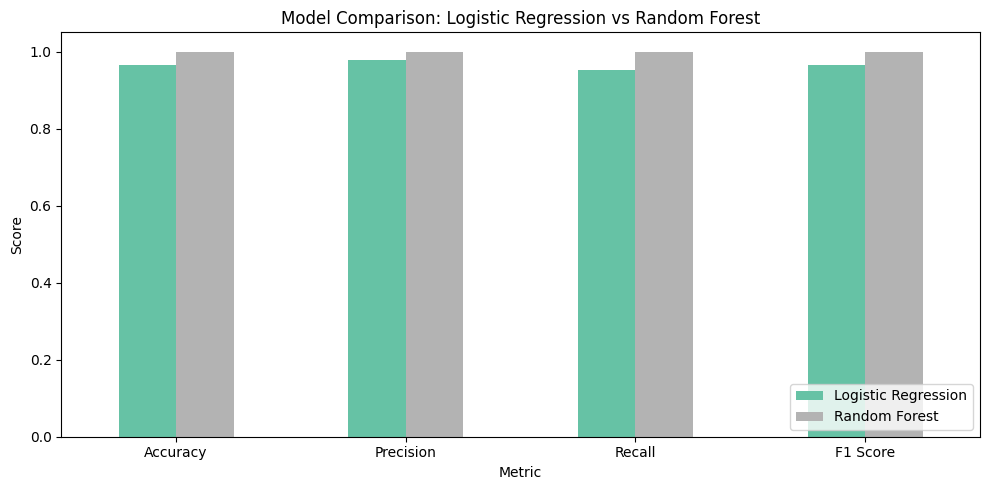

In [ ]:
# Comparison between both the models

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': [
        accuracy_score(y_test, lr_preds),
        precision_score(y_test, lr_preds),
        recall_score(y_test, lr_preds),
        f1_score(y_test, lr_preds)
    ],
    'Random Forest': [
        accuracy_score(y_test, rf_preds),
        precision_score(y_test, rf_preds),
        recall_score(y_test, rf_preds),
        f1_score(y_test, rf_preds)
    ]
})

results.set_index('Metric', inplace=True)
print(results.to_string())

results.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Model Comparison: Logistic Regression vs Random Forest')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Summary

**Random Forest outperforms Logistic Regression** across all four metrics (Accuracy, Precision, Recall, and F1 Score). This is because Random Forest is an ensemble method that builds multiple decision trees and combines their predictions, allowing it to capture complex non-linear patterns in the data that Logistic Regression cannot. Both models performed well overall due to the dataset being perfectly balanced (50/50 split between fraud and normal), which eliminates the class imbalance problem common in real-world fraud datasets. An interesting finding is that the dataset has **no missing values** and comes pre-processed with PCA-transformed features (V1-V28), making it clean and ready for modeling with minimal preprocessing needed.